In [18]:
#PACKAGES

#Load Key
import os
from dotenv import load_dotenv

load_dotenv()

assert os.getenv("GEMINI_API_KEY"), "API key not found"
print("API key loaded successfully")

#Initialize Gemini
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY")
)

response = llm.invoke("Say hello")
print(response.content)

#LangGraph
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

API key loaded successfully
Hello there! How can I help you today?


In [19]:
#TOOLS

@tool
def drug_lookup(drug_name: str) -> str:
    """Look up clinical information about a medication.
    Args:
        drug_name: The name of the drug (brand or generic)
    """
    
    drugs = {
        "warfarin": "Warfarin — Anticoagulant. Uses: blood clot prevention, atrial fibrillation. Side effects: bleeding, bruising.",
        "metformin": "Metformin — Biguanide. Uses: type 2 diabetes, insulin resistance. Side effects: nausea, diarrhea.",
        "lisinopril": "Lisinopril — ACE inhibitor. Uses: hypertension, heart failure. Side effects: dry cough, dizziness.",
        "insulin": "Insulin — Insulin analogue. Uses: type 1 & 2 diabetes. Side effects: hypoglycemia, weight gain.",
        "aspirin": "Aspirin — NSAID/Antiplatelet. Uses: pain relief, heart attack prevention. Side effects: stomach irritation, bleeding."
    }
    
    return drugs.get(drug_name.lower().strip(), f"Drug '{drug_name}' not found.")

@tool
def drug_interaction_checker(drug_a: str, drug_b: str) -> str:
    """Check if two drugs have known interactions.
    Args:
        drug_a: First drug name
        drug_b: Second drug name
    """
    
    interactions = {
        ("warfarin", "aspirin"): "HIGH RISK — Both increase bleeding risk. Avoid combination or monitor closely.",
        ("metformin", "insulin"): "MODERATE — Can cause hypoglycemia. Adjust doses carefully.",
        ("lisinopril", "aspirin"): "LOW RISK — May slightly reduce ACE inhibitor effectiveness.",
    }
    
    key1 = (drug_a.lower().strip(), drug_b.lower().strip())
    key2 = (drug_b.lower().strip(), drug_a.lower().strip())
    
    return interactions.get(key1, interactions.get(key2, f"No known interaction between {drug_a} and {drug_b}."))

@tool
def symptom_checker(symptoms: str) -> str:
    """Check possible conditions based on symptoms.
    Args:
        symptoms: Comma-separated symptoms (e.g., 'chest pain, fatigue')
    """
    
    condition_map = {
        "chest pain": ["Myocardial Infarction (I21)", "Angina Pectoris (I20)", "GERD (K21)"],
        "shortness of breath": ["Asthma (J45)", "Heart Failure (I50)", "COPD (J44)"],
        "frequent urination": ["Type 2 Diabetes (E11)", "UTI (N39.0)"],
        "blurred vision": ["Diabetic Retinopathy (E11.3)", "Glaucoma (H40)"],
        "fatigue": ["Anemia (D64.9)", "Hypothyroidism (E03)", "Depression (F32)"],
        "headache": ["Tension Headache (G44.2)", "Migraine (G43)", "Hypertension (I10)"]
    }
    
    results = []
    for s in symptoms.split(","):
        s = s.strip().lower()
        if s in condition_map:
            results.extend(condition_map[s])
            
    return f"Possible conditions: {', '.join(results)}" if results else f"No matches for: {symptoms}"

@tool
def condition_info(condition: str) -> str:
    """Get information about a medical condition.
    Args:
        condition: The name of the condition
    """
    
    conditions = {
        "diabetes": "Diabetes Mellitus — Chronic metabolic disorder. Types: Type 1, Type 2, Gestational. Key marker: HbA1c > 6.5%.",
        "hypertension": "Hypertension — Chronic elevated blood pressure (>140/90 mmHg). Risk factor for stroke, MI, kidney disease.",
        "asthma": "Asthma — Chronic airway inflammation. Symptoms: wheezing, cough, chest tightness.",
        "copd": "COPD — Progressive lung disease. Includes emphysema and chronic bronchitis. Main cause: smoking.",
        "heart failure": "Heart Failure — Heart can't pump enough blood. Symptoms: fatigue, edema, shortness of breath."
    }
    
    return conditions.get(condition.lower().strip(), f"No info found for '{condition}'.")

@tool
def interpret_lab_result(test_name: str, value: float) -> str:
    """Interpret a specific lab result value.
    Args:
        test_name: Name of the lab test
        value: The numeric result value
    """
    
    if test_name.lower() == "glucose":
        if value < 70: return f"Glucose {value} mg/dL — LOW (hypoglycemia)."
        elif value <= 100: return f"Glucose {value} mg/dL — NORMAL."
        elif value <= 125: return f"Glucose {value} mg/dL — PRE-DIABETIC."
        else: return f"Glucose {value} mg/dL — DIABETIC RANGE."
    elif test_name.lower() == "hba1c":
        if value < 5.7: return f"HbA1c {value}% — NORMAL."
        elif value <= 6.4: return f"HbA1c {value}% — PRE-DIABETIC."
        else: return f"HbA1c {value}% — DIABETIC."
    elif test_name.lower() == "hemoglobin":
        if value < 12: return f"Hemoglobin {value} g/dL — LOW. Possible anemia."
        elif value <= 17.5: return f"Hemoglobin {value} g/dL — NORMAL."
        else: return f"Hemoglobin {value} g/dL — HIGH."
            
    return f"Cannot interpret {test_name} = {value}."

In [20]:
#STATE

class State(TypedDict):
    messages: Annotated[list, add_messages]
    
    #Intake output — structured extraction from the patient query
    symptoms: list[str]
    drugs: list[str]
    lab_values: list[dict]      #e.g. [{"test": "glucose", "value": 142}]
    
    #Research output — collected findings from tools
    research_findings: list[str]
    
    #Quality check
    quality_approved: bool
    quality_feedback: str
    research_loops: int         #track how many times we've looped back

In [21]:
#PIPELINE AGENTS 

#Step 1: Intake (extract structured info from the patient query)
INTAKE_PROMPT = """You are a medical intake specialist. Read the patient query and extract:
1. Any symptoms mentioned (e.g., "chest pain", "fatigue")
2. Any drugs/medications mentioned (e.g., "warfarin", "insulin")  
3. Any lab values mentioned (e.g., "glucose 142", "hemoglobin 10")

Respond in EXACTLY this format (use empty lists if none found):
SYMPTOMS: symptom1, symptom2
DRUGS: drug1, drug2
LABS: test1=value1, test2=value2

Be precise. Only extract what is explicitly mentioned."""

def intake_agent(state: State):
    print(f"  📋 Step 1: Intake — extracting patient info...")
    
    messages = [SystemMessage(content=INTAKE_PROMPT)] + state["messages"]
    response = llm.invoke(messages)
    
    #Parse the structured response
    content = response.content
    symptoms = []
    drugs = []
    lab_values = []
    
    for line in content.split("\n"):
        line = line.strip()
        if line.startswith("SYMPTOMS:"):
            raw = line.replace("SYMPTOMS:", "").strip()
            if raw and raw.lower() != "none":
                symptoms = [s.strip() for s in raw.split(",") if s.strip()]
        elif line.startswith("DRUGS:"):
            raw = line.replace("DRUGS:", "").strip()
            if raw and raw.lower() != "none":
                drugs = [d.strip() for d in raw.split(",") if d.strip()]
        elif line.startswith("LABS:"):
            raw = line.replace("LABS:", "").strip()
            if raw and raw.lower() != "none":
                for pair in raw.split(","):
                    pair = pair.strip()
                    if "=" in pair:
                        test, val = pair.split("=", 1)
                        try:
                            lab_values.append({"test": test.strip(), "value": float(val.strip())})
                        except ValueError:
                            pass
    
    print(f"    Symptoms: {symptoms}")
    print(f"    Drugs: {drugs}")
    print(f"    Labs: {lab_values}")
    
    return {
        "messages": [response],
        "symptoms": symptoms,
        "drugs": drugs,
        "lab_values": lab_values,
        "research_findings": [],
        "quality_approved": False,
        "quality_feedback": "",
        "research_loops": 0
    }


#Step 2: Research (use tools to gather info based on what Intake extracted)
all_tools = [drug_lookup, drug_interaction_checker, symptom_checker, condition_info, interpret_lab_result]
llm_research = llm.bind_tools(all_tools)

RESEARCH_PROMPT = """You are a medical researcher. Based on the extracted patient information below,
use your tools to gather all relevant clinical data.

Symptoms: {symptoms}
Drugs: {drugs}
Lab values: {labs}
{feedback}

Your job:
- Look up each symptom using symptom_checker
- Look up each drug using drug_lookup  
- Check drug interactions if multiple drugs are mentioned
- Interpret each lab value using interpret_lab_result
- Get condition info if relevant conditions are identified

Be thorough. Use ALL relevant tools for every piece of information."""

def research_agent(state: State):
    loop_num = state.get("research_loops", 0) + 1
    print(f"  🔬 Step 2: Research (loop {loop_num}) — gathering clinical data...")
    
    symptoms = state.get("symptoms", [])
    drugs = state.get("drugs", [])
    labs = state.get("lab_values", [])
    feedback = state.get("quality_feedback", "")
    
    feedback_text = f"\n\nQuality feedback from previous attempt: {feedback}\nPlease address the gaps." if feedback else ""
    
    labs_str = ", ".join([f"{l['test']}={l['value']}" for l in labs]) if labs else "none"
    
    prompt = RESEARCH_PROMPT.format(
        symptoms=", ".join(symptoms) if symptoms else "none",
        drugs=", ".join(drugs) if drugs else "none",
        labs=labs_str,
        feedback=feedback_text
    )

    last_msg = state["messages"][-1] if state["messages"] else None
    
    if last_msg and last_msg.type == "tool":
        research_msgs = [SystemMessage(content=prompt), HumanMessage(content="Please research this patient case.")]
        for msg in state["messages"]:
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                if any(not tc["name"].startswith("handoff_") for tc in msg.tool_calls):
                    research_msgs.append(msg)
            elif msg.type == "tool":
                research_msgs.append(msg)
        response = llm_research.invoke(research_msgs)
    else:
        messages = [SystemMessage(content=prompt), HumanMessage(content="Please research this patient case.")]
        response = llm_research.invoke(messages)
    
    return {"messages": [response], "research_loops": loop_num}

#Step 2b: Research Tool Node (executes the tools the research agent called)
research_tool_node = ToolNode(tools=all_tools)


#Research ReAct loop (should research keep calling tools or move on?)
def should_research_continue(state: State):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "use_tools"
    return "quality_check"


#Step 3: Quality Check (evaluates if research is complete)
QUALITY_PROMPT = """You are a medical quality reviewer. Evaluate the research findings below.

Original patient info:
- Symptoms: {symptoms}
- Drugs: {drugs}  
- Lab values: {labs}

Research findings so far:
{findings}

Check:
1. Was every symptom looked up?
2. Was every drug looked up?
3. Were drug interactions checked (if multiple drugs)?
4. Were all lab values interpreted?
5. Was condition info retrieved for identified conditions?

If ALL relevant information has been gathered, respond with:
APPROVED

If something is missing, respond with:
NEEDS_WORK: [explain what's missing]"""

def quality_check(state: State):
    print(f"  ✅ Step 3: Quality Check — evaluating completeness...")
    
    symptoms = state.get("symptoms", [])
    drugs = state.get("drugs", [])
    labs = state.get("lab_values", [])
    
    #Collect all tool results as findings
    findings = []
    for msg in state["messages"]:
        if msg.type == "tool":
            findings.append(msg.content)
    
    labs_str = ", ".join([f"{l['test']}={l['value']}" for l in labs]) if labs else "none"
    
    prompt = QUALITY_PROMPT.format(
        symptoms=", ".join(symptoms) if symptoms else "none",
        drugs=", ".join(drugs) if drugs else "none",
        labs=labs_str,
        findings="\n".join(findings) if findings else "No findings yet."
    )
    
    messages = [SystemMessage(content=prompt), HumanMessage(content="Review the research.")]
    response = llm.invoke(messages)
    
    content = response.content.strip()
    
    if "APPROVED" in content:
        print(f"    ✅ Quality: APPROVED")
        return {
            "messages": [response],
            "quality_approved": True,
            "quality_feedback": "",
            "research_findings": findings
        }
    else:
        feedback = content.replace("NEEDS_WORK:", "").strip()
        print(f"    ❌ Quality: NEEDS WORK — {feedback[:100]}")
        return {
            "messages": [response],
            "quality_approved": False,
            "quality_feedback": feedback
        }


#Quality routing (approved or loop back?)
MAX_RESEARCH_LOOPS = 3

def route_after_quality(state: State):
    if state.get("quality_approved", False):
        return "report"
    if state.get("research_loops", 0) >= MAX_RESEARCH_LOOPS:
        print(f"  ⚠️ Max research loops ({MAX_RESEARCH_LOOPS}) reached. Moving to report.")
        return "report"
    return "research"


#Step 4: Report (final clinical summary)
REPORT_PROMPT = """You are a senior clinician writing a final case summary.
Based on all the research findings below, write a concise clinical report.

Patient presented with:
- Symptoms: {symptoms}
- Medications: {drugs}
- Lab values: {labs}

Research findings:
{findings}

Write a clear, structured clinical summary that includes:
1. Key findings
2. Possible diagnoses
3. Medication concerns (if any)
4. Recommended next steps

Be concise and clinical."""

def report_agent(state: State):
    print(f"  📝 Step 4: Report — writing clinical summary...")
    
    symptoms = state.get("symptoms", [])
    drugs = state.get("drugs", [])
    labs = state.get("lab_values", [])
    findings = state.get("research_findings", [])
    
    #Also grab any tool results not yet in findings
    for msg in state["messages"]:
        if msg.type == "tool" and msg.content not in findings:
            findings.append(msg.content)
    
    labs_str = ", ".join([f"{l['test']}={l['value']}" for l in labs]) if labs else "none"
    
    prompt = REPORT_PROMPT.format(
        symptoms=", ".join(symptoms) if symptoms else "none",
        drugs=", ".join(drugs) if drugs else "none",
        labs=labs_str,
        findings="\n".join(findings) if findings else "No findings."
    )
    
    messages = [SystemMessage(content=prompt), HumanMessage(content="Write the report.")]
    response = llm.invoke(messages)
    
    return {"messages": [response]}

Graph compiled!


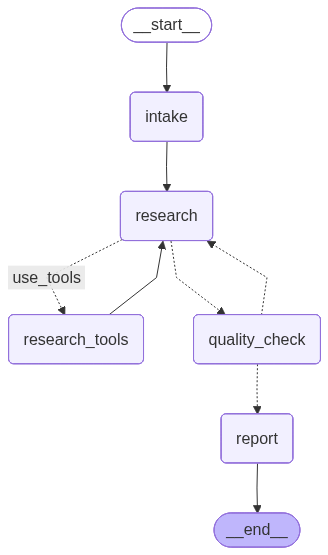

In [22]:
#BUILD, COMPILE AND VISUALIZE GRAPH

graph_builder = StateGraph(State)

#Nodes (4 pipeline steps + tool node)
graph_builder.add_node("intake", intake_agent)
graph_builder.add_node("research", research_agent)
graph_builder.add_node("research_tools", research_tool_node)
graph_builder.add_node("quality_check", quality_check)
graph_builder.add_node("report", report_agent)

#Edges (the pipeline sequence)
graph_builder.add_edge(START, "intake")                  
graph_builder.add_edge("intake", "research")            

#Research ReAct loop
graph_builder.add_conditional_edges("research", should_research_continue, {
    "use_tools": "research_tools",
    "quality_check": "quality_check"
})
graph_builder.add_edge("research_tools", "research")     

#Quality gate (the conditional loop)
graph_builder.add_conditional_edges("quality_check", route_after_quality, {
    "report": "report",
    "research": "research"
})

graph_builder.add_edge("report", END)                  

graph = graph_builder.compile()
print("Graph compiled!")

#Visualize
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [23]:
#RUN AGENT

def run_agent(question: str):
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print(f"{'='*60}")
    
    events = graph.stream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="values"
    )
    
    for event in events:
        last_msg = event["messages"][-1]
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tc in last_msg.tool_calls:
                print(f"    🔧 Tool: {tc['name']}({tc['args']})")
        elif last_msg.type == "tool":
            print(f"    📋 Result: {last_msg.content[:200]}")
        elif last_msg.type == "ai" and last_msg.content:
            #Check which step produced this
            if "SYMPTOMS:" in last_msg.content:
                pass  
            elif "APPROVED" in last_msg.content or "NEEDS_WORK" in last_msg.content:
                pass 
            else:
                print(f"\n  🤖 Final Report:\n{last_msg.content}")

In [24]:
#TESTS

run_agent("What are the side effects of aspirin?")
run_agent("My patient has shortness of breath and fatigue. What could it be?")
run_agent("My patient has chest pain and is on warfarin and aspirin.")
run_agent("Patient's hemoglobin is 10 g/dL and glucose is 180 mg/dL.")
run_agent("Diabetic patient on metformin and insulin, glucose 142, hemoglobin 10, with fatigue and blurred vision.")


Question: What are the side effects of aspirin?
  📋 Step 1: Intake — extracting patient info...
    Symptoms: []
    Drugs: ['aspirin']
    Labs: []
  🔬 Step 2: Research (loop 1) — gathering clinical data...
    🔧 Tool: symptom_checker({'symptoms': 'none'})
    🔧 Tool: drug_lookup({'drug_name': 'aspirin'})
    📋 Result: Aspirin — NSAID/Antiplatelet. Uses: pain relief, heart attack prevention. Side effects: stomach irritation, bleeding.
  🔬 Step 2: Research (loop 2) — gathering clinical data...

  🤖 Final Report:
Patient reports no symptoms. Aspirin is used for pain relief and heart attack prevention. Side effects include stomach irritation and bleeding.
  ✅ Step 3: Quality Check — evaluating completeness...
    ❌ Quality: NEEDS WORK — Was condition info retrieved for identified conditions?
  🔬 Step 2: Research (loop 3) — gathering clinical data...
    🔧 Tool: symptom_checker({'symptoms': 'none'})
    🔧 Tool: drug_lookup({'drug_name': 'aspirin'})
    📋 Result: Aspirin — NSAID/Antiplate